Name: Aarya Malghe
PRN: 2023011000061

In [1]:
# Install XAI libraries
!pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=314b680d16b67c536a253c5cefd951386095f93d3523aec6c700fa89d5965235
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Explainable AI
import shap
from lime.lime_tabular import LimeTabularExplainer

# For better visualization
sns.set(style="whitegrid")

#Part 1: Dataset Selection and Preprocessing

In [15]:
# Load Titanic dataset from online source
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
# Dataset info
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB
None


In [18]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64


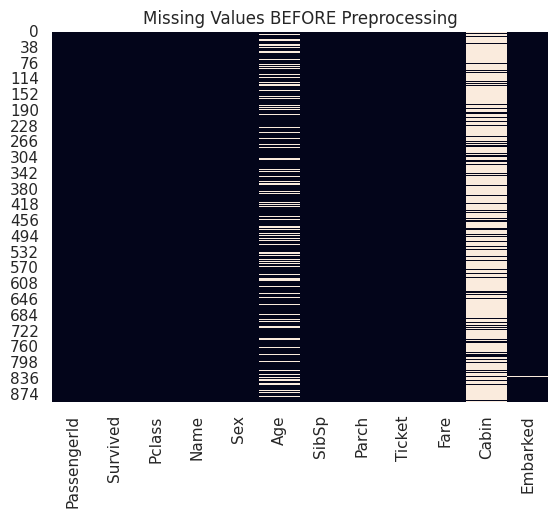

In [27]:
# Reload original dataset
df_raw = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

plt.figure()
sns.heatmap(df_raw.isnull(), cbar=False)
plt.title("Missing Values BEFORE Preprocessing")
plt.show()

In [20]:
df = df.drop(['PassengerId'], axis=1)

print("\nColumns after dropping unnecessary ones:")
print(df.columns)


Columns after dropping unnecessary ones:
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [21]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Verify missing values are removed
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipykernel_799/994897202.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_799/994897202.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [22]:
# Convert categorical columns into numerical
df = pd.get_dummies(df, drop_first=True)

print("\nDataset after encoding:")
print(df.head())


Dataset after encoding:
   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [23]:
X = df.drop('Survived', axis=1)
y = df['Survived']

print("\nFeature columns:")
print(X.columns)


Feature columns:
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain/Test Split:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Train/Test Split:
X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


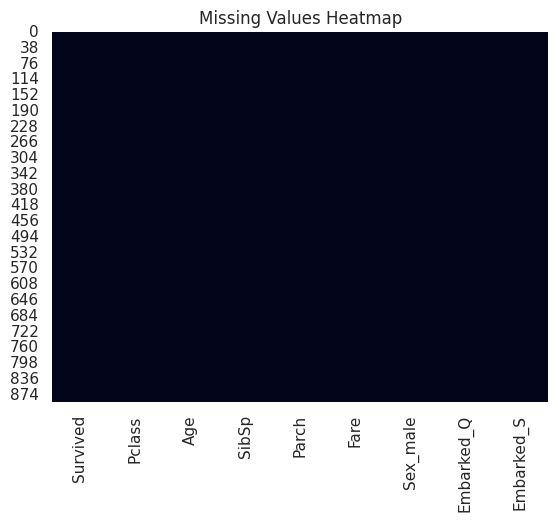

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

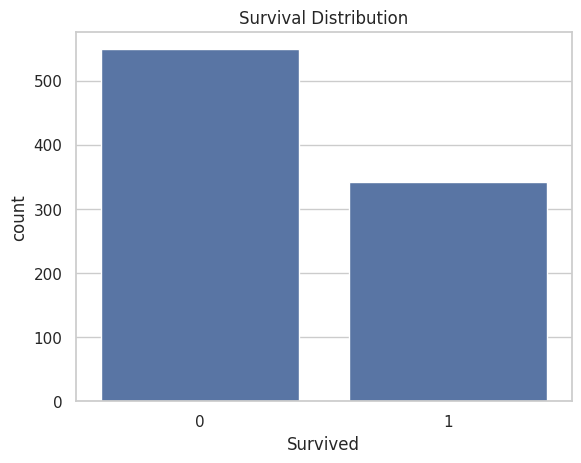

In [26]:
plt.figure()
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

#PART 2: MODEL IMPLEMENTATION

In [28]:
# Machine Learning libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [29]:
# Create Random Forest model
# n_estimators = number of trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model on training data
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [30]:
# Predict on test data
y_pred = model.predict(X_test)

# Show first 10 predictions
print("First 10 Predictions:", y_pred[:10])
print("Actual Values:", y_test.values[:10])

First 10 Predictions: [0 0 0 1 0 1 1 0 1 1]
Actual Values: [1 0 0 1 1 1 1 0 1 1]


In [31]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8212290502793296


In [32]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



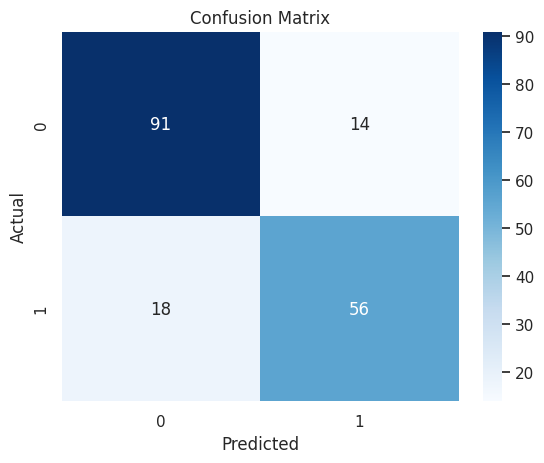

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

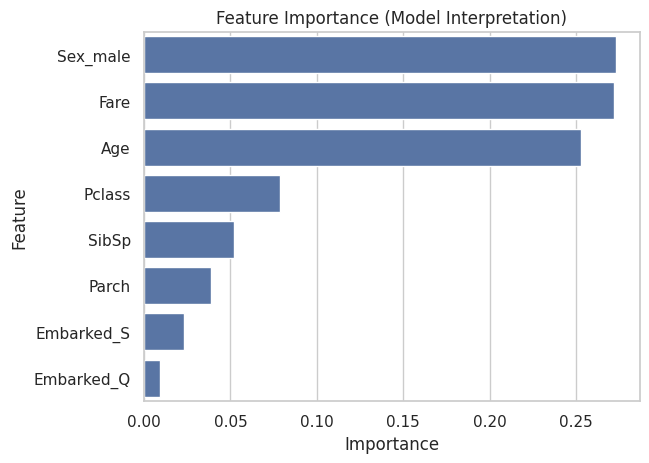

In [34]:
# Extract feature importance
importances = model.feature_importances_
features = X.columns

# Create DataFrame
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance (Model Interpretation)")
plt.show()

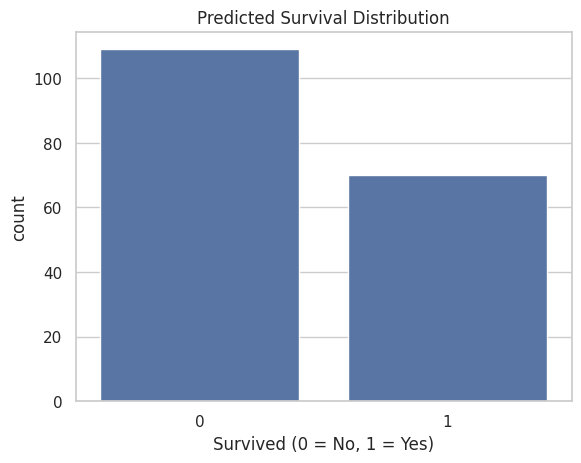

In [35]:
plt.figure()
sns.countplot(x=y_pred)
plt.title("Predicted Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.show()

#Part 3: Applying Explainable AI Techniques

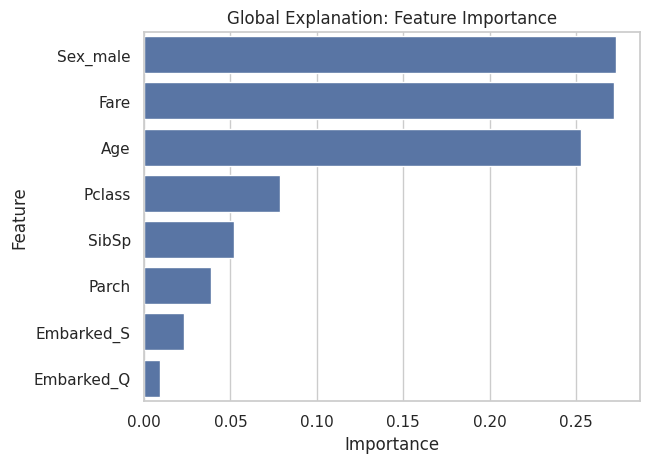

In [36]:
# Get feature importance from Random Forest
importances = model.feature_importances_
features = X.columns

# Create DataFrame
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Global Explanation: Feature Importance")
plt.show()

In [37]:
!pip install shap

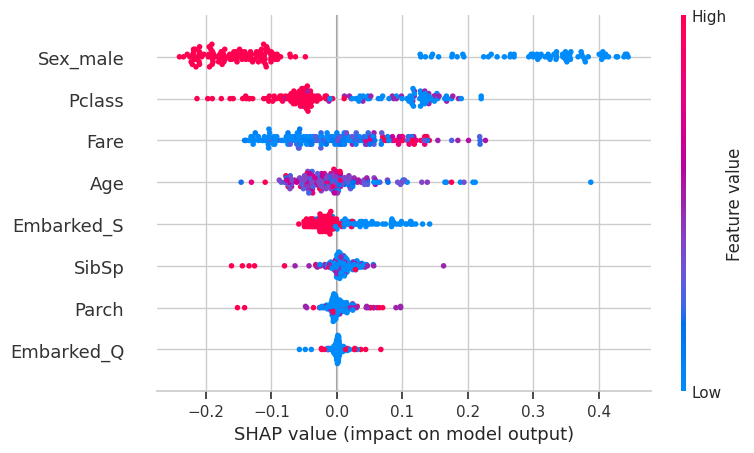

In [40]:
import shap

# Ensure numeric (you already did this)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Use TreeExplainer (better for Random Forest)
explainer = shap.TreeExplainer(model)

# Disable additivity check
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Plot
shap.summary_plot(shap_values[:, :, 1], X_test)

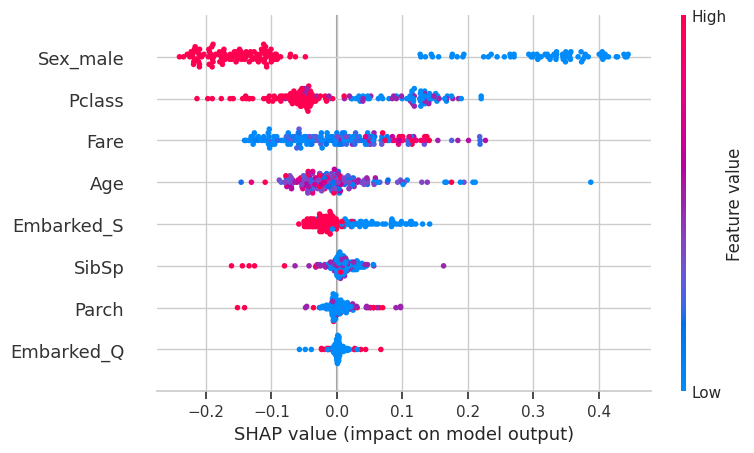

In [41]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test, check_additivity=False)

# Global plot
shap.summary_plot(shap_values[:, :, 1], X_test)

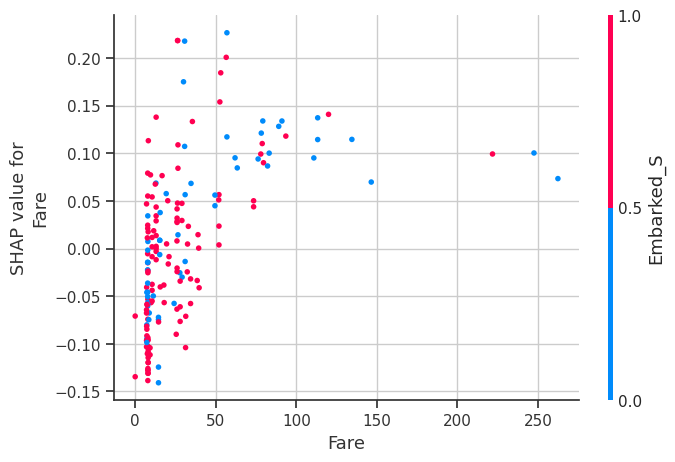

In [43]:
shap.dependence_plot("Fare", shap_values[:, :, 1], X_test)

In [44]:
!pip install lime

In [45]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    mode='classification'
)

# Select one instance
i = 5

# Explain prediction
exp = lime_explainer.explain_instance(
    X_test.iloc[i],
    model.predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

In [47]:
shap.initjs()

shap.plots.force(
    explainer.expected_value[1],     # base value
    shap_values[:, :, 1][0],         # SHAP values for one sample
    X_test.iloc[0]                   # feature values
)

#PART 4: VISUALIZATION & ANALYSIS

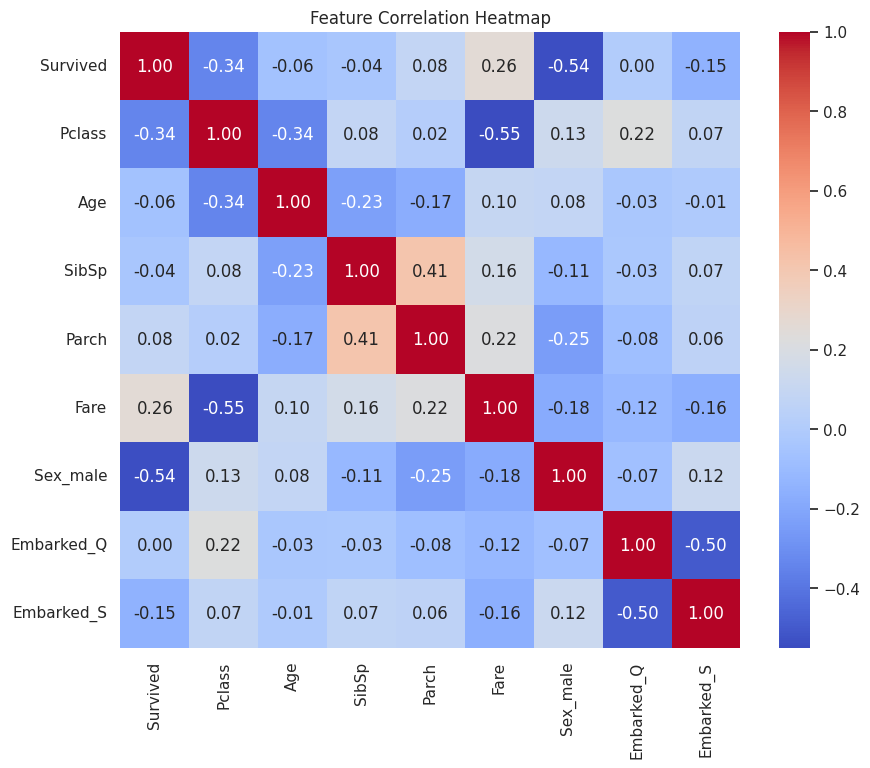

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

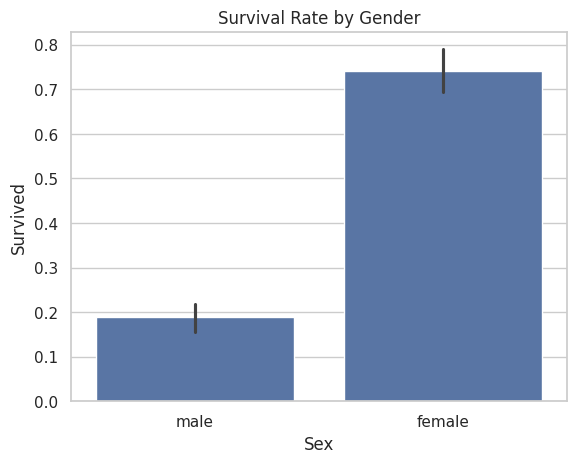

In [50]:
plt.figure()
sns.barplot(x='Sex', y='Survived', data=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"))
plt.title("Survival Rate by Gender")
plt.show()

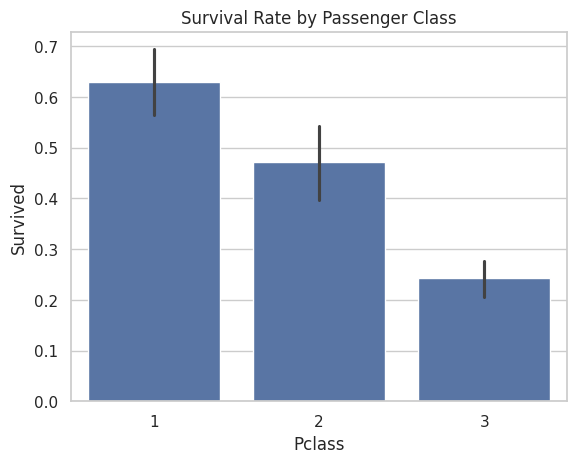

In [51]:
plt.figure()
sns.barplot(x='Pclass', y='Survived', data=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"))
plt.title("Survival Rate by Passenger Class")
plt.show()

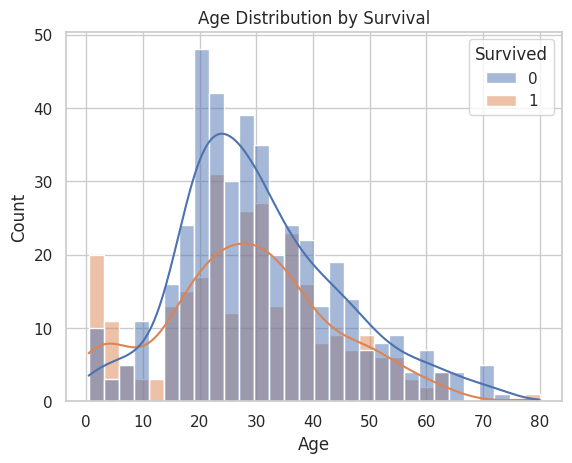

In [52]:
plt.figure()
sns.histplot(data=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"),
             x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

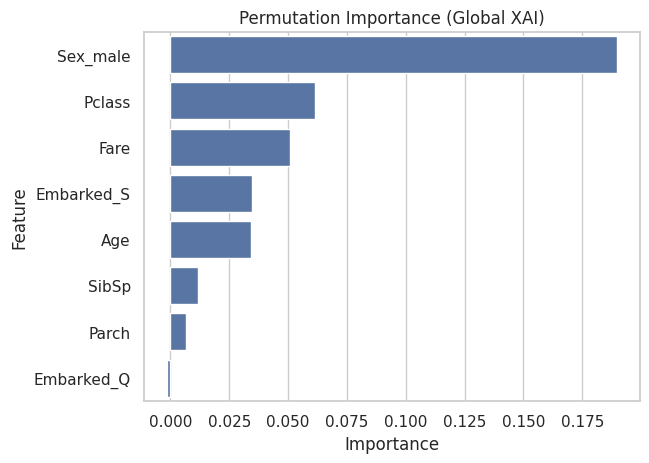

In [53]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=perm_df)
plt.title("Permutation Importance (Global XAI)")
plt.show()

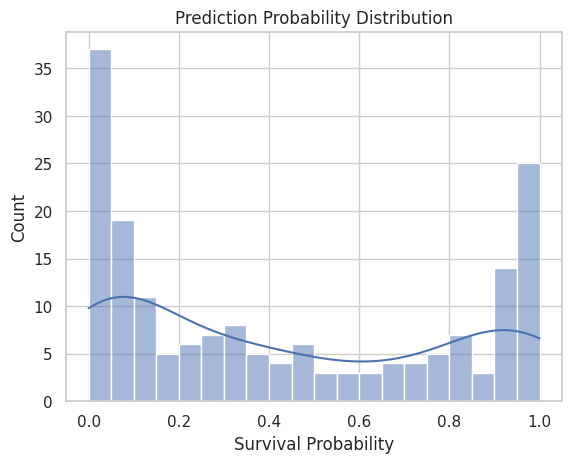

In [54]:
y_prob = model.predict_proba(X_test)[:,1]

plt.figure()
sns.histplot(y_prob, bins=20, kde=True)
plt.title("Prediction Probability Distribution")
plt.xlabel("Survival Probability")
plt.show()